In [ ]:
!pip install catboost econml dask[dataframe]

In [ ]:
!pip install category_encoders

In [1]:
import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow
import catboost
from catboost import CatBoostClassifier
import pyarrow.dataset as ds
import gcsfs
import gc
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from econml.panel.dml import DynamicDML
from econml.dml import CausalForestDML

from xgboost import XGBRegressor,XGBClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import GradientBoostingRegressor
import itertools
from typing import List, Tuple, Dict

# =========================================================
# =============== USER CONFIGURATION ======================
# =========================================================

N_BOOT = 250                # Number of bootstrap samples
RANDOM_STATE = 42

In [2]:
from typing import List, Dict, Any, Tuple

from causal_preproc.T import optimal_binning_dml,create_joint_treatment_labels
from causal_preproc.utils import clean_and_reconcile_pricing, add_seasonal_harmonics, filter_rare_categories,apply_ordinal_encoding

from causal_preproc.X import create_thresholded_heterogeneous_features
from causal_preproc.W import multi_ordered_target_encode, catboost_style_encoding, apply_catboost_encoding
from causal_preproc.visualizations import plot_T_histogram, plot_cate_heatmaps
from causal_preproc.model_utils import  train_causal_models,compute_and_aggregate_cates#

In [ ]:
client = bigquery.Client()
#table_ref = "expanded-nebula-754.sandbox_devanh.pnaPhase3p5"
table_ref =  "expanded-nebula-754.sandbox_devanh.pnaPhase3"
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")
print(len(df))

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.
13522191


In [ ]:
#df.to_csv('df_test_all.csv')

In [ ]:
import hashlib
print(len(df))
def hash_mod(ts, mod=16):
    h = hashlib.sha256(str(ts).encode()).hexdigest()
    return int(h, 16) % mod

df['keep'] = df['event_timestamp_posix'].apply(lambda ts: hash_mod(ts) == 0)
df = df[df['keep']].copy()
df.reset_index(drop=True, inplace=True)
print(len(df))
gc.collect()

13522191
846453


33

In [ ]:
#df.to_csv('df_test.csv')

In [3]:
df = pd.read_csv('df_test.csv')

In [4]:


W_cols_cat= ['customer_size_bucket']#ENCODE,'sub_region'
W_cols_cont = ['days_since_last_purchase']
X_cols_cat_het = ['data_definition','country','channel','industry']
X_cols_cat = []
#X_cols_cat= ['industry' , \
#              'customer_size_bucket']#ENCODE'warehouse', ,'product_brand'


T_cols_cont = ['discount_percentage','avg_dead_clicks_per_session_6_months_pre','pdp_completeness','lead_time']

In [5]:
session_cols = ['ga_session_id','participant_id','event_timestamp_posix']
view_cols = ['viewed_sku_14_to_8_days_ago','viewed_sku_21_to_15_days_ago','viewed_sku_7_days_to_1_second_ago']
purchase_cols = ['purchases_sku_order_lines_1_second_to_7_days_in_the_future','purchases_sku_order_lines_8_days_to_14_days_in_the_future']#


df['viewed_sku'] =  df['viewed_sku_7_days_to_1_second_ago'] + df['viewed_sku_21_to_15_days_ago']	+ df['viewed_sku_14_to_8_days_ago']#df_copy['purchased_sku_order_lines_7_days_to_1_second_ago']	+
df['purchased_sku']  =  df['purchases_sku_order_lines_1_second_to_7_days_in_the_future'] +	df['purchases_sku_order_lines_8_days_to_14_days_in_the_future']# + \
	  #df_copy['purchases_sku_order_lines_15_days_to_21_days_in_the_future']# +df_copy['purchased_sku_order_lines_21_to_15_days_ago'] +	df_copy['purchased_sku_order_lines_14_to_8_days_ago']


price_cols = [
    'list_price_per_item_euros',
    'discounted_price_per_item_euros',
    'discount_percentage'
]


import gc
gc.collect()

df['customer_size_total_revenue_euros'] = pd.to_numeric(
    df['customer_size_total_revenue_euros'], errors='coerce'
)


all_cols = session_cols + view_cols + purchase_cols + price_cols + W_cols_cat + W_cols_cont+ X_cols_cat + X_cols_cat_het+ T_cols_cont# + confouder_cols
df_copy = df[all_cols].copy()




del df
gc.collect()


df_copy = df_copy.loc[:, ~df_copy.columns.duplicated()].copy()

#df_copy = df.copy()
df_copy['viewed_sku'] =  df_copy['viewed_sku_7_days_to_1_second_ago'] + df_copy['viewed_sku_21_to_15_days_ago']	+ df_copy['viewed_sku_14_to_8_days_ago']#df_copy['purchased_sku_order_lines_7_days_to_1_second_ago']	+
df_copy['purchased_sku']  =  df_copy['purchases_sku_order_lines_1_second_to_7_days_in_the_future'] +	df_copy['purchases_sku_order_lines_8_days_to_14_days_in_the_future']




df_copy['pdp_completeness'] = pd.to_numeric(df_copy['pdp_completeness'], errors='coerce').fillna(0)
df_copy['avg_dead_clicks_per_session_6_months_pre'] = pd.to_numeric(df_copy['avg_dead_clicks_per_session_6_months_pre'], errors='coerce').fillna(0)
df_copy['viewed_sku'] = pd.to_numeric(df_copy['viewed_sku'], errors='coerce').fillna(0)
df_copy['purchased_sku'] = pd.to_numeric(df_copy['purchased_sku'], errors='coerce').fillna(0)

# Convert >0 to 1, everything else to 0
df_copy['viewed_sku'] = (df_copy['viewed_sku'] > 0).astype(int)
df_copy['purchased_sku'] = (df_copy['purchased_sku'] > 0).astype(int)



df_copy[price_cols] =df_copy[price_cols].apply(
    lambda col: col.mask(col.isna() | (col < 0.01), 0.0)
)

df_copy.reset_index(drop=True, inplace=True)
gc.collect()



0

In [6]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()

def fillna_mixed(
    df,
    str_val='',
    num_val=0,
    bool_val=False,
    dt_val=pd.NaT,
):
    out = df.copy()

    str_cols = out.select_dtypes(include=["object", "string"]).columns
    num_cols = out.select_dtypes(include=["number"]).columns
    bool_cols = out.select_dtypes(include=["bool", "boolean"]).columns
    dt_cols = out.select_dtypes(include=["datetime", "datetimetz"]).columns
    cat_cols = out.select_dtypes(include=["category"]).columns

    out.loc[:, str_cols] = out.loc[:, str_cols].fillna(str_val)
    out.loc[:, num_cols] = out.loc[:, num_cols].fillna(num_val)
    out.loc[:, bool_cols] = out.loc[:, bool_cols].fillna(bool_val)
    out.loc[:, dt_cols] = out.loc[:, dt_cols].fillna(dt_val)

    for c in cat_cols:
        out[c] = out[c].cat.add_categories([str_val]).fillna(str_val)

    return out


df_copy = fillna_mixed(df_copy)

target_col = "purchased_sku_binary"
# 1) Coerce to numeric, treat non-numeric/NaN as 0
y_num = pd.to_numeric(df_copy["purchased_sku"], errors="coerce").fillna(0)

# 2) Binary mapping: any value > 0 -> 1, else 0
df_copy["purchased_sku_binary"] = (y_num > 0).astype(int)

# 3) Sanity checks
print("Uniques after binarization:", df_copy["purchased_sku_binary"].unique().tolist())
print(df_copy["purchased_sku_binary"].value_counts(dropna=False))


df_copy['discount_response'] = df_copy['discounted_price_per_item_euros']*df_copy['purchased_sku_binary']

Uniques after binarization: [0, 1]
purchased_sku_binary
0    672898
1    173555
Name: count, dtype: int64


In [7]:

X_cols_raw = X_cols_cat_het+X_cols_cat
print(len(df_copy))
df_copy = filter_rare_categories(df_copy, X_cols_raw, 0.045)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453
Column 'data_definition': Kept 5 categories. Others mapped to __NONE__.
Column 'country': Kept 2 categories. Others mapped to __NONE__.
Column 'channel': Kept 5 categories. Others mapped to __NONE__.
Column 'industry': Kept 5 categories. Others mapped to __NONE__.
846453


In [8]:
print(len(df_copy))
df_copy = clean_and_reconcile_pricing(df_copy,price_cols)

df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()



846453
Rows set to 0 due to NaNs in any of ['list_price_per_item_euros', 'discounted_price_per_item_euros', 'discount_percentage']: 0
Rows corrected where list_price_per_item_euros < discounted_price_per_item_euros: 94731
count    846453.000000
mean          0.084152
std           0.159767
min           0.000000
1%            0.000000
50%           0.000000
99%           0.729748
max           1.000000
Name: discount_percentage, dtype: float64
846453


0

In [9]:
df_copy,new_cat_cols_X = apply_ordinal_encoding(df_copy, X_cols_raw)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453


In [10]:
df_copy,new_cat_cols_W = apply_ordinal_encoding(df_copy, W_cols_cat)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453


In [11]:
df_copy,cb_encoded_X_cols = apply_catboost_encoding(df_copy,df_copy[target_col], new_cat_cols_X)#catboost_style_encoding(df_copy, new_cat_cols_X, target_col, n_splits=5, global_smoothing=10, max_combination_size=2)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453


In [12]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))
df_copy,cb_encoded_W_cols = apply_catboost_encoding(df_copy,df_copy[target_col], new_cat_cols_W)

df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))
print(cb_encoded_W_cols)

846453
846453
['customer_size_bucket_ord_encoded']


In [13]:
cb_encoded_W_cols

['customer_size_bucket_ord_encoded']

In [14]:
cb_encoded_X_cols

['data_definition_ord_encoded',
 'country_ord_encoded',
 'channel_ord_encoded',
 'industry_ord_encoded']

In [15]:
df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()
#Daily: 24 * 60 * 60 = 86,400
#Weekly: 7 * 86,400 = 604,800
# Monthly (approx 30.44 days): 30.44 * 86,400 = 2,630,016
harmonic_periods = (
    #('daily', 86400),
    ('weekly', 604800),
    ('monthly', 2630016)
)

df_copy, W_time_confounder_cols = add_seasonal_harmonics(df_copy, 'event_timestamp_posix', harmonic_periods)

df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()

846453
846453


0

In [16]:
df_copy['discounted_price_per_item_euros_log1p'] = np.log1p(pd.to_numeric(df_copy['discounted_price_per_item_euros']*df_copy['purchased_sku_binary'], errors='coerce').fillna(0))

gc.collect()
df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()

846453


0

In [17]:
df_copy['purchased_sku_binary'].dtype
column = df_copy['purchased_sku_binary']

# Count NaNs
nan_count = column.isna().sum()
nan_count

np.int64(0)

In [ ]:
import gc
# Fix: remove the assignment when using inplace=True, or remove inplace=True when assigning.discount_percentage
df_copy['pdp_completeness'] = df_copy['pdp_completeness'].fillna(0.0)
df_copy['avg_dead_clicks_per_session_6_months_pre'] = df_copy['avg_dead_clicks_per_session_6_months_pre'].fillna(0.0)
df_copy['discount_percentage'] = df_copy['discount_percentage'].fillna(0.0)
df_copy['lead_time'] = df_copy['lead_time'].fillna(0.0)
df_copy['discounted_price_per_item_euros_log1p'] = df_copy['discounted_price_per_item_euros_log1p'].fillna(0.0)

#'avg_frustration_score_per_session_6_months_pre',
gc.collect()
df_copy.reset_index(drop=True, inplace=True)
print(f"Rows: {len(df_copy)}")
#print(df_copy[['pdp_completeness', 'discounted_price_per_item_euros_log1p','discount_percentage']].describe())
print(df_copy[['lead_time','discount_percentage','avg_dead_clicks_per_session_6_months_pre','pdp_completeness']].describe())

Rows: 846453
           lead_time  discount_percentage  \
count  846453.000000        846453.000000   
mean        2.429978             0.073399   
std         6.465699             0.136191   
min         0.000000             0.000000   
25%         0.000000             0.000000   
50%         0.000000             0.000000   
75%         0.000000             0.098592   
max        30.000000             0.650000   

       avg_dead_clicks_per_session_6_months_pre  pdp_completeness  
count                             846453.000000     846453.000000  
mean                                   3.569558         67.910344  
std                                    8.128689         26.781971  
min                                    0.000000          0.000000  
25%                                    0.299145         65.460000  
50%                                    1.000000         77.723333  
75%                                    2.782609         84.873333  
max                                  

In [18]:
df_copy.loc[df_copy['discount_percentage'] < 0, 'discount_percentage'] = 0
df_copy.loc[df_copy['discount_percentage'] > 0.6, 'discount_percentage'] = 0

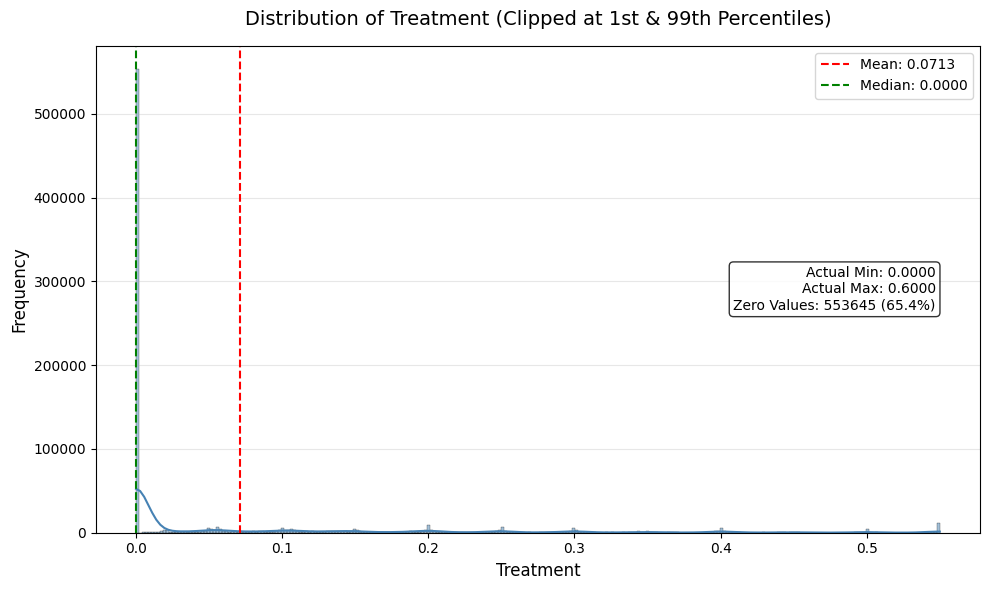

In [19]:
plot_T_histogram(df_copy['discount_percentage'].values, clip_outliers=True)

In [20]:
df_copy.loc[df_copy['lead_time'] < 1.2, 'lead_time'] = 0
df_copy.loc[df_copy['lead_time'] > 61, 'lead_time'] = 0
#df_copy.loc[df_copy['pdp_completeness'] < 27, 'pdp_completeness'] = 0.0

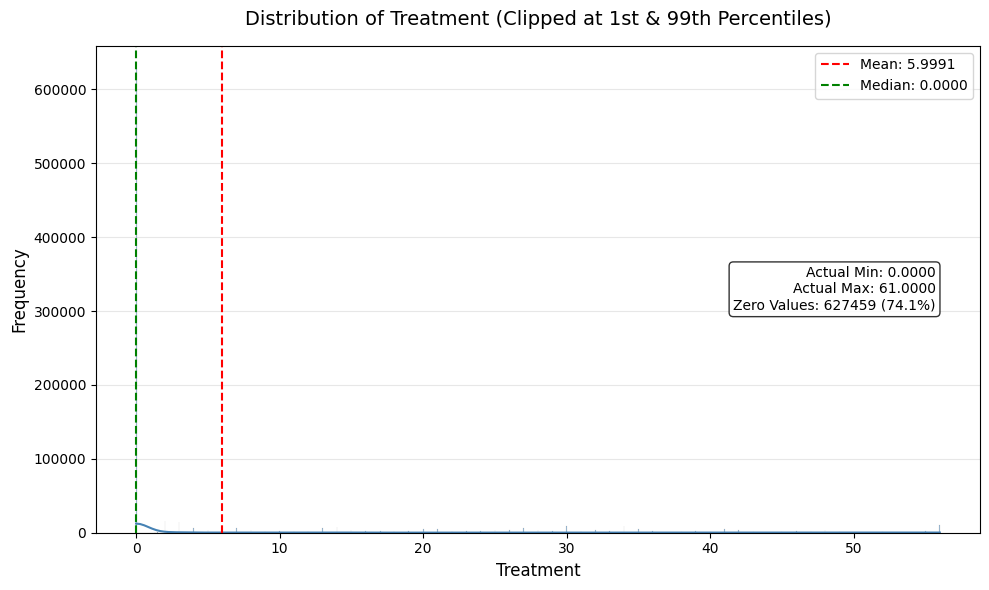

In [21]:
plot_T_histogram(df_copy['lead_time'].values, clip_outliers=True)

In [22]:
df_copy.loc[df_copy['avg_dead_clicks_per_session_6_months_pre'] > 20, 'avg_dead_clicks_per_session_6_months_pre'] = 0.0
df_copy.loc[df_copy['pdp_completeness'] < 27, 'pdp_completeness'] = 0.0
# Verify the change
#print(f"Minimum value in pdp_completeness: {df_copy['avg_dead_clicks_per_session_6_months_pre'].min()}")
#display(df_copy['avg_dead_clicks_per_session_6_months_pre'].describe())

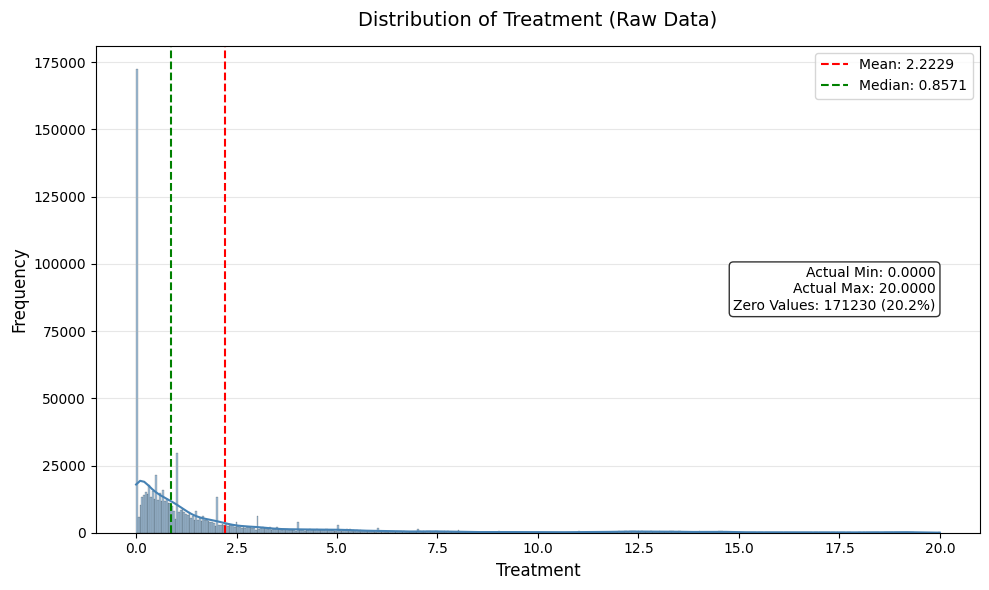

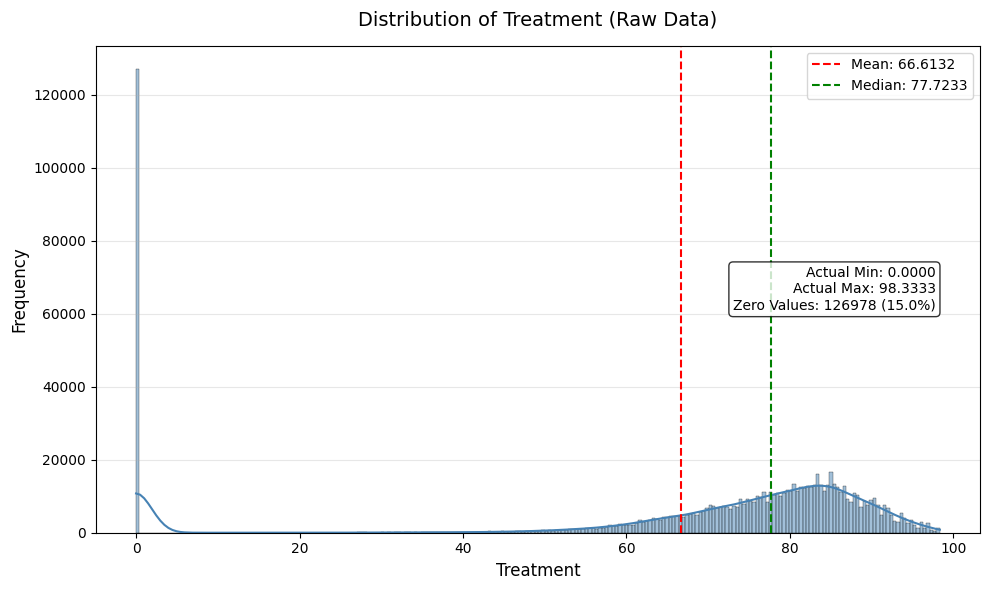

In [23]:
plot_T_histogram(df_copy['avg_dead_clicks_per_session_6_months_pre'].values, clip_outliers=False)
plot_T_histogram(df_copy['pdp_completeness'].values, clip_outliers=False)

In [24]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))
df_copy,T_ohe_disc_cols = optimal_binning_dml(df_copy, ['discount_percentage'], target="purchased_sku_binary", bin_candidates=(3,4,5), frac=0.6, drop_zero_bin=False, random_state=42)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453
846453


In [25]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))
df_copy,T_ohe_dclicks_cols = optimal_binning_dml(df_copy, ['avg_dead_clicks_per_session_6_months_pre'], target="purchased_sku_binary", bin_candidates=(3,4,5), frac=0.6, drop_zero_bin=False, random_state=42)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453
846453


In [26]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))
df_copy,T_ohe_pdp_cols = optimal_binning_dml(df_copy, ['pdp_completeness'], target="purchased_sku_binary", bin_candidates=(3,4,5), frac=0.6, drop_zero_bin=False, random_state=42)
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453
846453


In [27]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

df_copy,T_ohe_lead_cols = optimal_binning_dml(df_copy, ['lead_time'], target="purchased_sku_binary", bin_candidates=(3,4,5), frac=0.6, drop_zero_bin=False, random_state=42)#[2]
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df_copy))

846453
846453


In [28]:
print(T_ohe_lead_cols)
print(T_ohe_disc_cols)

['lead_time_baseline_0.0', 'lead_time_0.0_to_11.817', 'lead_time_11.817_to_inf']
['discount_percentage_baseline_0.0', 'discount_percentage_0.0_to_0.296', 'discount_percentage_0.296_to_inf']


In [28]:
print(T_ohe_disc_cols)
print(T_ohe_dclicks_cols)
print(T_ohe_pdp_cols)
print(T_ohe_lead_cols)

['discount_percentage_baseline_0.0', 'discount_percentage_0.0_to_0.0577', 'discount_percentage_0.0577_to_0.1', 'discount_percentage_0.1_to_0.129', 'discount_percentage_0.129_to_0.296', 'discount_percentage_0.296_to_inf']
['avg_dead_clicks_per_session_6_months_pre_baseline_0.0', 'avg_dead_clicks_per_session_6_months_pre_0.0_to_0.495', 'avg_dead_clicks_per_session_6_months_pre_0.495_to_0.988', 'avg_dead_clicks_per_session_6_months_pre_0.988_to_inf']
['pdp_completeness_baseline_0.0', 'pdp_completeness_0.0_to_64.448', 'pdp_completeness_64.448_to_89.368', 'pdp_completeness_89.368_to_inf']
['lead_time_baseline_0.0', 'lead_time_0.0_to_4.917', 'lead_time_4.917_to_12.866', 'lead_time_12.866_to_25.775', 'lead_time_25.775_to_31.875', 'lead_time_31.875_to_inf']


In [29]:
print(cb_encoded_W_cols)
print(W_cols_cont)
print(W_time_confounder_cols)
print(cb_encoded_X_cols)
print(X_cols_cat_het)

['customer_size_bucket_ord_encoded']
['days_since_last_purchase']
['event_timestamp_posix_sin_weekly', 'event_timestamp_posix_cos_weekly', 'event_timestamp_posix_sin_monthly', 'event_timestamp_posix_cos_monthly']
['data_definition_ord_encoded', 'country_ord_encoded', 'channel_ord_encoded', 'industry_ord_encoded']
['data_definition', 'country', 'channel', 'industry']


In [30]:
df_copy.reset_index(drop=True, inplace=True)
gc.collect()
W_cols = cb_encoded_W_cols + W_cols_cont + W_time_confounder_cols
W_cols

['customer_size_bucket_ord_encoded',
 'days_since_last_purchase',
 'event_timestamp_posix_sin_weekly',
 'event_timestamp_posix_cos_weekly',
 'event_timestamp_posix_sin_monthly',
 'event_timestamp_posix_cos_monthly']

In [31]:
X_cols = cb_encoded_X_cols#ohe_feature_names_X +cb_encoded_X_cols
X_cols

['data_definition_ord_encoded',
 'country_ord_encoded',
 'channel_ord_encoded',
 'industry_ord_encoded']

In [32]:
X_cols_cat_het

['data_definition', 'country', 'channel', 'industry']

In [33]:
df_copy, joint_col_name =create_joint_treatment_labels(
    df=df_copy,
    discount_cols=T_ohe_disc_cols,
    lead_cols=T_ohe_lead_cols,
    joint_col_name = "joint_treatment"
)

df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()

846453


0

In [34]:
#treatments_config = [{'discount_lead_joint':joint_col_name}]
treatments_config = [{'discount_lead_joint': ['joint_treatment']}]

In [ ]:
#print(df_copy.head(2))

In [33]:
treatments_config = [{'discount':T_ohe_disc_cols},
                     {'dead_clicks':T_ohe_dclicks_cols},
                     {'pdp_completeness':T_ohe_pdp_cols},
                     {'leads':T_ohe_lead_cols}]

In [ ]:


trained_models = train_causal_models(
    df=df_copy,
    X_cols=X_cols,
    W_cols=W_cols,
    y_col='discounted_price_per_item_euros_log1p',
    treatments_config=treatments_config
)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:


# Execute the computation
aggregated_results = compute_and_aggregate_cates(
    df=df_copy,
    X_cols=X_cols,
    heterogeneous_cat_cols=X_cols_cat_het,
    trained_models=trained_models
)

In [ ]:


# Re-run plotting
plot_cate_heatmaps(
    aggregated_results=aggregated_results,
    cmap="coolwarm",
    figsize=(24, 14)
)

In [ ]:
#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt

# 1. Transform the list of dictionaries into a flat DataFrame
#plot_data_list = []

#for entry in results:
#    bin_name = entry['bin']#

    # Process Country CATEs
#    for country, cate_val in entry['data_definition'].items():
#        plot_data_list.append({
#            'Treatment Bin': bin_name,
#            'Feature': 'Country',
#            'Category': country,
#            'CATE': cate_val
#        })

    # Process Channel CATEs
#    for channel, cate_val in entry['country'].items():
#        plot_data_list.append({
#            'Treatment Bin': bin_name,
#            'Feature': 'Channel',
#            'Category': channel,
#            'CATE': cate_val
#        })

#results_df = pd.DataFrame(plot_data_list)

# 2. Create the visualizations
#fig, axes = plt.subplots(1, 2, figsize=(25, 15))

# Heatmap for Country
#country_pivot = results_df[results_df['Feature'] == 'Country'].pivot(index='Category', columns='Treatment Bin', values='CATE')
#sns.heatmap(country_pivot, annot=True, cmap='RdYlGn', center=0, ax=axes[0])
#axes[0].set_title('Average CATE by Country and Treatment Bin')
#axes[0].set_ylabel('Country')

# Heatmap for Channel
#channel_pivot = results_df[results_df['Feature'] == 'Channel'].pivot(index='Category', columns='Treatment Bin', values='CATE')
#sns.heatmap(channel_pivot, annot=True, cmap='RdYlGn', center=0, ax=axes[1])
#axes[1].set_title('Average CATE by Channel and Treatment Bin')
#axes[1].set_ylabel('Channel')

#plt.tight_layout()
#plt.show()

In [ ]:
'''
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

#T = df_copy[T_disc_bins].values
W = df_copy[W_cols].values
Y= df_copy['discounted_price_per_item_euros_log1p'].values
X = df_copy[ohe_feature_names_X].values

#Y = Y
#X = X
#W = W
T_pdp = df_copy[T_pdp_bins].copy()

base_model_y = RandomForestRegressor(n_estimators=100)
base_model_t = RandomForestClassifier(n_estimators=100)



gc.collect()

results = []

#X_disc_ohe =  df_copy[T_fs].values#T_lead_ohe_df.values
print("\n--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---")
gc.collect()
for i in range(1, len(T_pdp_bins)):
    t_val = T_pdp_bins[i]
    #print(t_val)
    T = T_pdp.iloc[:, i].values



    # Causal Forest DML setup
    est = CausalForestDML(
        model_y=base_model_y,
        model_t=base_model_t,
        discrete_treatment=True,
        cv=3,


        n_estimators=1000,                 # final forest; keep ≥ 200–300 even for debug
        max_samples=0.45,                 # fraction per tree (default for CF)
        min_samples_leaf=10,


        criterion='mse',
        #min_samples_leaf=5
    )
    est.fit(Y, T=T, X=X,W=W)
    df_copy['cate'] = est.effect(X)
    print(t_val)
    gc.collect()#'product_business_division','product_business_division_expanded','product_business_unit'
    results.append({
      'bin': t_val,
      'data_definition': df_copy.groupby(mapped_text_names_X[0],observed=False)['cate'].mean(),
      'country': df_copy.groupby(mapped_text_names_X[1],observed=False)['cate'].mean(),

    }
  )

print("\n--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---")

T_fs = df_copy[T_fs_bins].copy()

for i in range(1, len(T_fs_bins)):
    t_val = T_fs_bins[i]
    T = T_fs.iloc[:, i].values


    gc.collect()
    # Causal Forest DML setup
    est = CausalForestDML(
        model_y=base_model_y,
        model_t=base_model_t,
        discrete_treatment=True,
        cv=3,
        n_estimators=1000,                 # final forest; keep ≥ 200–300 even for debug
        max_samples=0.45,                 # fraction per tree (default for CF)
        min_samples_leaf=10,

        criterion='mse',
    )
    est.fit(Y, T, X=X,W=W)
    df_copy['cate'] = est.effect(X)
    print(t_val)
    gc.collect()
    results.append({
      'bin': t_val,
      'data_definition': df_copy.groupby(mapped_text_names_X[0],observed=False)['cate'].mean(),
      'country': df_copy.groupby(mapped_text_names_X[1],observed=False)['cate'].mean(),

  })

'''

In [ ]:
'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pdp_histogram(pdp_scores, clip_outliers=False):
    """
    Plots a histogram of PDP completeness scores, automatically handling
    unknown bounds and distributions.

    Parameters:
    pdp_scores (array-like): The floating point PDP scores.
    clip_outliers (bool): If True, clips data to the 1st and 99th percentiles
                          to visualize the core distribution if extreme outliers exist.
    """
    # Convert to pandas Series and drop NaNs to prevent plotting errors
    data = pd.Series(pdp_scores).dropna()

    if len(data) == 0:
        print("Error: The provided data is empty or contains only NaNs.")
        return

    # Calculate summary statistics to display on the plot
    p_min = data.min()
    p_max = data.max()
    p_mean = data.mean()
    p_median = data.median()
    zeros_count = (data == 0.0).sum()
    zeros_pct = (zeros_count / len(data)) * 100

    # Handle extreme outliers for better visualization if requested
    if clip_outliers:
        lower_bound = data.quantile(0.01)
        upper_bound = data.quantile(0.99)
        data = data.clip(lower=lower_bound, upper=upper_bound)
        title_suffix = " (Clipped at 1st & 99th Percentiles)"
    else:
        title_suffix = " (Raw Data)"

    # Set up the plot
    plt.figure(figsize=(10, 6))

    # Plot histogram with KDE (Kernel Density Estimate) and automatic binning
    sns.histplot(data, bins='auto', kde=True, color='steelblue', stat='count')

    # Add vertical lines for mean and median to immediately identify skewness
    plt.axvline(p_mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {p_mean:.4f}')
    plt.axvline(p_median, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {p_median:.4f}')

    # Add text box with distribution bounds and zero-inflation check
    stats_text = (
        f"Actual Min: {p_min:.4f}\n"
        f"Actual Max: {p_max:.4f}\n"
        f"Zero Values: {zeros_count} ({zeros_pct:.1f}%)"
    )
    plt.gca().text(0.95, 0.5, stats_text, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='center', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Formatting
    plt.title(f'Distribution of PDP Completeness Scores{title_suffix}', fontsize=14, pad=15)
    plt.xlabel('PDP Completeness Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

'''

In [ ]:
'''
def filter_rare_categories(df, categorical_cols, threshold, replacement="__NONE__"):
    """
    Replaces rare categories in the specified columns with a replacement value
    rather than dropping the rows.

    Parameters:
    - df (pd.DataFrame): Input DataFrame
    - categorical_cols (list): List of column names
    - threshold (float): Minimum frequency threshold (0.0 to 1.0)
    - replacement (str): The value to use for rare categories

    Returns:
    - pd.DataFrame: Modified DataFrame
    """
    df_filtered = df.copy()

    for col in categorical_cols:
        # Calculate frequencies
        freq = df_filtered[col].value_counts(normalize=True)
        # Identify categories that meet the threshold
        valid_categories = freq[freq >= threshold].index

        # If the column is a Categorical type, we must add the replacement to the categories first
        if pd.api.types.is_categorical_dtype(df_filtered[col]):
            if replacement not in df_filtered[col].cat.categories:
                df_filtered[col] = df_filtered[col].cat.add_categories([replacement])

        # Replace values not in valid_categories with the replacement string
        df_filtered.loc[~df_filtered[col].isin(valid_categories), col] = replacement

        print(f"Column '{col}': Kept {len(valid_categories)} categories. Others mapped to {replacement}.")

    return df_filtered
'''

In [ ]:
"""
df_copy.reset_index(drop=True, inplace=True)
gc.collect()

def fillna_mixed(
    df,
    str_val='',
    num_val=0,
    bool_val=False,
    dt_val=pd.NaT,
):
    out = df.copy()

    str_cols = out.select_dtypes(include=["object", "string"]).columns
    num_cols = out.select_dtypes(include=["number"]).columns
    bool_cols = out.select_dtypes(include=["bool", "boolean"]).columns
    dt_cols = out.select_dtypes(include=["datetime", "datetimetz"]).columns
    cat_cols = out.select_dtypes(include=["category"]).columns

    out.loc[:, str_cols] = out.loc[:, str_cols].fillna(str_val)
    out.loc[:, num_cols] = out.loc[:, num_cols].fillna(num_val)
    out.loc[:, bool_cols] = out.loc[:, bool_cols].fillna(bool_val)
    out.loc[:, dt_cols] = out.loc[:, dt_cols].fillna(dt_val)

    for c in cat_cols:
        # Fix: Only add category if it doesn't already exist
        if str_val not in out[c].cat.categories:
            out[c] = out[c].cat.add_categories([str_val])
        out[c] = out[c].fillna(str_val)

    return out


df_copy = fillna_mixed(df_copy)

target_col = "purchased_sku_binary"
# 1) Coerce to numeric, treat non-numeric/NaN as 0
y_num = pd.to_numeric(df_copy["purchased_sku"], errors="coerce").fillna(0)

# 2) Binary mapping: any value > 0 -> 1, else 0
df_copy["purchased_sku_binary"] = (y_num > 0).astype(int)

# 3) Sanity checks
print("Uniques after binarization:", df_copy["purchased_sku_binary"].unique().tolist())
print(df_copy["purchased_sku_binary"].value_counts(dropna=False))


df_copy['discount_response'] = df_copy['discounted_price_per_item_euros']*df_copy['purchased_sku_binary']



gc.collect()
df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()
"""

Uniques after binarization: [0, 1]
purchased_sku_binary
0    85052
1    21956
Name: count, dtype: int64
107008


0

In [ ]:
"""
def apply_ordinal_encoding(df: pd.DataFrame, cols_to_encode: list) -> Tuple[pd.DataFrame, list]:
    if not cols_to_encode:
        return df, []

    enc = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        dtype=int
    )

    # Fit and transform
    encoded = enc.fit_transform(df[cols_to_encode])

    new_cols = [f"{c}_ord" for c in cols_to_encode]

    # Create temporary DataFrame for the encoded columns
    encoded_df = pd.DataFrame(
        encoded,
        columns=new_cols,
        index=df.index
    ).astype('Int64')

    # Concatenate and cleanup
    df = pd.concat([df, encoded_df], axis=1)
    gc.collect()

    return df, new_cols

# Example usage for X_cols_raw:
# df_copy, new_cat_cols_X = apply_ordinal_encoding(df_copy, X_cols_raw)
# print(f"Created columns: {new_cat_cols_X}")
"""

In [ ]:
"""
def compute_and_aggregate_cates(
    df: pd.DataFrame,
    X_cols: List[str],
    heterogeneous_cat_cols: List[str],
    trained_models: Dict[str, Dict[str, Any]]
) -> Dict[str, Dict[str, Any]]:
with both OHE treatment inputs and encoded single-column categorical inputs.
    X = df[X_cols].values

    # DataFrame to temporarily hold row-level CATE predictions
    cates_df = df[heterogeneous_cat_cols].copy()
    treatment_order = []

    for treatment_name, model_info in trained_models.items():
        model = model_info['model']
        # This contains either the OHE column names or the decoded string categories
        level_labels = model_info['ohe_cols']

        # Skip index 0 as it is the control group (T0=0)
        for i in range(1, len(level_labels)):
            treatment_level_name = level_labels[i]
            treatment_order.append((treatment_name, treatment_level_name))

            # Compute conditional average treatment effect using the integer index i
            cates_df[treatment_level_name] = model.effect(X, T0=0, T1=i)

    # Aggregate by the specified heterogeneous categorical variables
    aggregated_results = {}
    ordered_level_names = [t[1] for t in treatment_order]

    for cat_col in heterogeneous_cat_cols:
        # Group by the heterogeneous feature and calculate the mean CATE
        agg_df = cates_df.groupby(cat_col, observed=False)[ordered_level_names].mean()

        aggregated_results[cat_col] = {
            'data': agg_df,
            'treatment_order': treatment_order
        }

    return aggregated_results
"""

In [ ]:

"""
enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',  # don't crash on unseen categories
    unknown_value=-1,                    # code for unknown categories at transform time
    dtype=int,
    # If your scikit-learn supports it, also set missing encoding:
    # encoded_missing_value=-1
)

# Fit on training data
enc.fit(df_copy[X_cols_raw])
gc.collect()


encoded = enc.transform(df_copy[X_cols_raw])
new_cat_cols_X = [f"{c}_ord" for c in X_cols_raw]

encoded_df = pd.DataFrame(
    encoded,
    columns=new_cat_cols_X,#[f"{c}_ord" for c in cat_cols],
    index=df_copy.index
).astype('Int64')  # pandas nullable integer dtype (keeps NA if present)

df_copy = pd.concat([df_copy, encoded_df], axis=1)
gc.collect()
print(new_cat_cols_X)
"""

'\nenc = OrdinalEncoder(\n    handle_unknown=\'use_encoded_value\',  # don\'t crash on unseen categories\n    unknown_value=-1,                    # code for unknown categories at transform time\n    dtype=int,\n    # If your scikit-learn supports it, also set missing encoding:\n    # encoded_missing_value=-1\n)\n\n# Fit on training data\nenc.fit(df_copy[X_cols_raw])\ngc.collect()\n\n\nencoded = enc.transform(df_copy[X_cols_raw])\nnew_cat_cols_X = [f"{c}_ord" for c in X_cols_raw]\n\nencoded_df = pd.DataFrame(\n    encoded,\n    columns=new_cat_cols_X,#[f"{c}_ord" for c in cat_cols],\n    index=df_copy.index\n).astype(\'Int64\')  # pandas nullable integer dtype (keeps NA if present)\n\ndf_copy = pd.concat([df_copy, encoded_df], axis=1)\ngc.collect()\nprint(new_cat_cols_X)\n'

In [ ]:
"""
enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',  # don't crash on unseen categories
    unknown_value=-1,                    # code for unknown categories at transform time
    dtype=int,

)

# Fit on training data
enc.fit(df_copy[W_cols_cat])
gc.collect()


encoded = enc.transform(df_copy[W_cols_cat])
new_cat_cols_W = [f"{c}_ord" for c in W_cols_cat]
encoded_df = pd.DataFrame(
    encoded,
    columns=new_cat_cols_W,#[f"{c}_ord" for c in cat_cols],
    index=df_copy.index
).astype('Int64')  # pandas nullable integer dtype (keeps NA if present)

df_copy = pd.concat([df_copy, encoded_df], axis=1)
gc.collect()
"""

0